In [70]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore")

In [71]:
df = pd.read_csv('dataset/assignment-2.csv')
df.head()

,Age,AnnualIncome,CreditScore,LoanAmount,LoanTerm(years),EmploymentType,loan
0,28,6.5,720,5,5,Salaried,0
1,45,12.0,680,10,10,Self-Employed,1
2,35,8.0,750,6,7,Salaried,0
3,50,15.0,640,12,15,Self-Employed,1
4,30,7.0,710,5,5,Salaried,0


In [72]:
df.describe()

,Age,AnnualIncome,CreditScore,LoanAmount,LoanTerm(years),loan
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,39.700000,10.300000,686.000000,8.100000,9.100000,0.500000
std,9.922477,3.750556,42.739521,3.071373,4.012481,0.527046
min,26.000000,5.500000,620.000000,4.000000,4.000000,0.000000
25%,31.250000,7.250000,652.500000,5.250000,5.500000,0.000000
50%,40.000000,9.500000,690.000000,8.000000,9.000000,0.500000
75%,47.250000,13.500000,717.500000,10.750000,11.500000,1.000000
max,55.000000,16.000000,750.000000,12.000000,15.000000,1.000000


In [73]:
# One-Hot Encoding using get_dummies
df.columns
df["EmploymentType"] = df[" EmploymentType"].replace({
    "Salaried": 0,
    "Self-Employed": 1
})

In [74]:
# removed existing column
df.drop(" EmploymentType", axis=1, inplace=True)

In [75]:
X = df[['Age', 'AnnualIncome', 'CreditScore', 'LoanAmount', 'LoanTerm(years)', 'EmploymentType']]
Y = df[['loan']]

In [76]:
# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [77]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [78]:
inertia = [] #to find out best k

for k in range(1, 5):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=8)
    kmeans.fit(X_train_scaled)
    inertia.append(kmeans.inertia_)

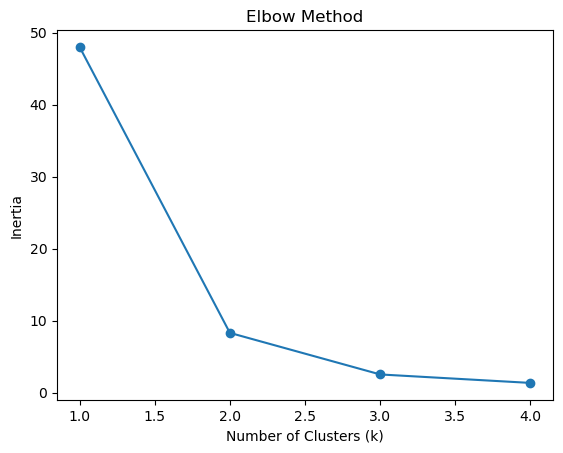

In [79]:
plt.figure()
plt.plot(range(1, 5), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

In [80]:
# Train KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, Y_train)

# Predictions
Y_pred = knn.predict(X_test_scaled)

print(confusion_matrix(Y_test, Y_pred))
print(classification_report(Y_test, Y_pred))

[[1 0]
 [0 1]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [82]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, Y_train)
dt_pred = dt.predict(X_test)

In [83]:
# Q1. Identify high-risk customers ?
# --> Age: 42+ LoanTerm: 10+ LoanAmount > 9
high_risk = df[df["loan"] == 1]
high_risk

,Age,AnnualIncome,CreditScore,LoanAmount,LoanTerm(years),loan,EmploymentType
1,45,12.0,680,10,10,1,1
3,50,15.0,640,12,15,1,1
5,42,10.0,660,9,10,1,0
7,48,14.0,650,11,12,1,1
9,55,16.0,620,12,15,1,1


In [84]:
# Q2. What Patterns Lead to Default?
# --> Low credit score + High loan amount = Default
df.groupby("loan")[["CreditScore","AnnualIncome","LoanAmount"]].mean()

,CreditScore,AnnualIncome,LoanAmount
loan,,,
0,722.0,7.2,5.4
1,650.0,13.4,10.8


In [85]:
# Q3. How Credit Score & Income Influence Prediction?
df.corr()

,Age,AnnualIncome,CreditScore,LoanAmount,LoanTerm(years),loan,EmploymentType
Age,1.000000,0.984972,-0.899197,0.985487,0.980398,0.881732,0.850039
AnnualIncome,0.984972,1.000000,-0.910116,0.985780,0.983452,0.871254,0.906431
CreditScore,-0.899197,-0.910116,1.000000,-0.919232,-0.910962,-0.887875,-0.775290
LoanAmount,0.985487,0.985780,-0.919232,1.000000,0.981838,0.926638,0.882696
LoanTerm(years),0.980398,0.983452,-0.910962,0.981838,1.000000,0.866921,0.836536
loan,0.881732,0.871254,-0.887875,0.926638,0.866921,1.000000,0.816497
EmploymentType,0.850039,0.906431,-0.775290,0.882696,0.836536,0.816497,1.000000


In [87]:
# Q4. Suggest Banking Policies (Based on Data)
# Reject loan if credit score < 650.
# LoanAmount ≤ 70% of AnnualIncome.
# If CreditScore < 680 → max 7 years.
# Extra verification for Self-Employed

In [88]:
# Q5. Should KNN Be Used in Real-Time Loan Approval?
# --> No
# Issue
# KNN stores full dataset.
# Prediction = compute distance with all records.
# Slow when data grows.
# Hard to explain decision to regulators.

# Better for Real-Time:
# Decision Tree
# Random Forest
# Logistic Regression



In [ ]:
# Q.6 What Happens If LoanAmount Dominates Distance?
# If not scaled:
# Distance formula becomes dominated by:
# LoanAmount differences.
# Example:
# LoanAmount difference = 5
# CreditScore difference = 20
# But if ranges differ heavily, model will prioritize larger-scale feature.
# Result:
# Model ignores CreditScore importance.
# StandardScaler()
# is mandatory for KNN.